# Exploratory Data Analysis: MAESTRO Metadata

Library Imports


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Setting the style


In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# For high-res plots
%config InlineBackend.figure_format = 'retina'

Config paths for the dataset

In [3]:
maestro_path = Path("../data/raw/maestro-v3.0.0")  
metadata_file = maestro_path / "maestro-v3.0.0.csv"

In [ ]:
df = pd.read_csv(metadata_file)

In [6]:
df.head()

,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration
0,Alban Berg,Sonata Op. 1,train,2018,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,2018/MIDI-Unprocessed_Chamber3_MID--AUDIO_10_R...,698.661160
1,Alban Berg,Sonata Op. 1,train,2008,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,2008/MIDI-Unprocessed_03_R2_2008_01-03_ORIG_MI...,759.518471
2,Alban Berg,Sonata Op. 1,train,2017,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,2017/MIDI-Unprocessed_066_PIANO066_MID--AUDIO-...,464.649433
3,Alexander Scriabin,"24 Preludes Op. 11, No. 13-24",train,2004,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,2004/MIDI-Unprocessed_XP_21_R1_2004_01_ORIG_MI...,872.640588
4,Alexander Scriabin,"3 Etudes, Op. 65",validation,2006,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MI...,397.857508


General Statistics

In [7]:
# Basic statistics
print("Dataset Statistics:")

print(f"\nTotal recordings: {len(df)}")
print(f"Total duration: {df['duration'].sum() / 3600:.1f} hours")
print(f"Average duration: {df['duration'].mean():.1f} seconds")
print(f"Shortest recording: {df['duration'].min():.1f} seconds")
print(f"Longest recording: {df['duration'].max():.1f} seconds")

print(f"\nYears covered: {df['year'].min()} - {df['year'].max()}")
print(f"Unique composers: {df['canonical_composer'].nunique()}")
print(f"Unique titles: {df['canonical_title'].nunique()}")

Dataset Statistics:

Total recordings: 1276
Total duration: 198.7 hours
Average duration: 560.5 seconds
Shortest recording: 45.2 seconds
Longest recording: 2624.7 seconds

Years covered: 2004 - 2018
Unique composers: 60
Unique titles: 854


In [ ]:
df[(df['year'] == 2004) & (df['split'] == 'validation')]

,canonical_composer,canonical_title,split,year,midi_filename,audio_filename,duration
206,Franz Liszt,"Hungarian Rhapsody, No. 12",validation,2004,2004/MIDI-Unprocessed_XP_11_R1_2004_03-04_ORIG...,2004/MIDI-Unprocessed_XP_11_R1_2004_03-04_ORIG...,569.204517
271,Franz Liszt,"Transcendental Etude No. 9, 'Ricordanza'",validation,2004,2004/MIDI-Unprocessed_XP_01_R1_2004_04-05_ORIG...,2004/MIDI-Unprocessed_XP_01_R1_2004_04-05_ORIG...,510.895929
789,Johann Sebastian Bach,"Prelude and Fugue in D Minor, Book II",validation,2004,2004/MIDI-Unprocessed_XP_09_R1_2004_01-02_ORIG...,2004/MIDI-Unprocessed_XP_09_R1_2004_01-02_ORIG...,203.718416
868,Johannes Brahms,"16 Waltzes, Op. 39",validation,2004,2004/MIDI-Unprocessed_XP_14_R1_2004_01-03_ORIG...,2004/MIDI-Unprocessed_XP_14_R1_2004_01-03_ORIG...,1064.859038
921,Joseph Haydn,"Sonata in D Major, Hob. XVI:24",validation,2004,2004/MIDI-Unprocessed_XP_19_R1_2004_01-02_ORIG...,2004/MIDI-Unprocessed_XP_19_R1_2004_01-02_ORIG...,208.260069
938,Ludwig van Beethoven,15 Variations and Fugue in Eb on an Original T...,validation,2004,2004/MIDI-Unprocessed_SMF_13_01_2004_01-05_ORI...,2004/MIDI-Unprocessed_SMF_13_01_2004_01-05_ORI...,1402.554623
943,Ludwig van Beethoven,"Eroica Variations, Op. 35",validation,2004,2004/MIDI-Unprocessed_XP_10_R1_2004_01-02_ORIG...,2004/MIDI-Unprocessed_XP_10_R1_2004_01-02_ORIG...,1314.696976
1087,Mily Balakirev,Islamei,validation,2004,2004/MIDI-Unprocessed_XP_04_R1_2004_06_ORIG_MI...,2004/MIDI-Unprocessed_XP_04_R1_2004_06_ORIG_MI...,530.857408
1140,Robert Schumann,"Davidsbundlertanze, Op. 6",validation,2004,2004/MIDI-Unprocessed_XP_19_R1_2004_01-02_ORIG...,2004/MIDI-Unprocessed_XP_19_R1_2004_01-02_ORIG...,2097.178642
1180,Sergei Rachmaninoff,"Elegy Op. 3, No. 1",validation,2004,2004/MIDI-Unprocessed_SMF_16_R1_2004_01-08_ORI...,2004/MIDI-Unprocessed_SMF_16_R1_2004_01-08_ORI...,321.438154


Are there any NA values?


In [9]:
df.isna().any().any()

np.False_

Train, validation and test splits


Detailed Split Statistics:
Train       :  962 files |  159.2h total |  9.93 min avg | ±  7.69 min std
Validation  :  137 files |   19.4h total |  8.51 min avg | ±  7.10 min std
Test        :  177 files |   20.0h total |  6.77 min avg | ±  4.90 min std


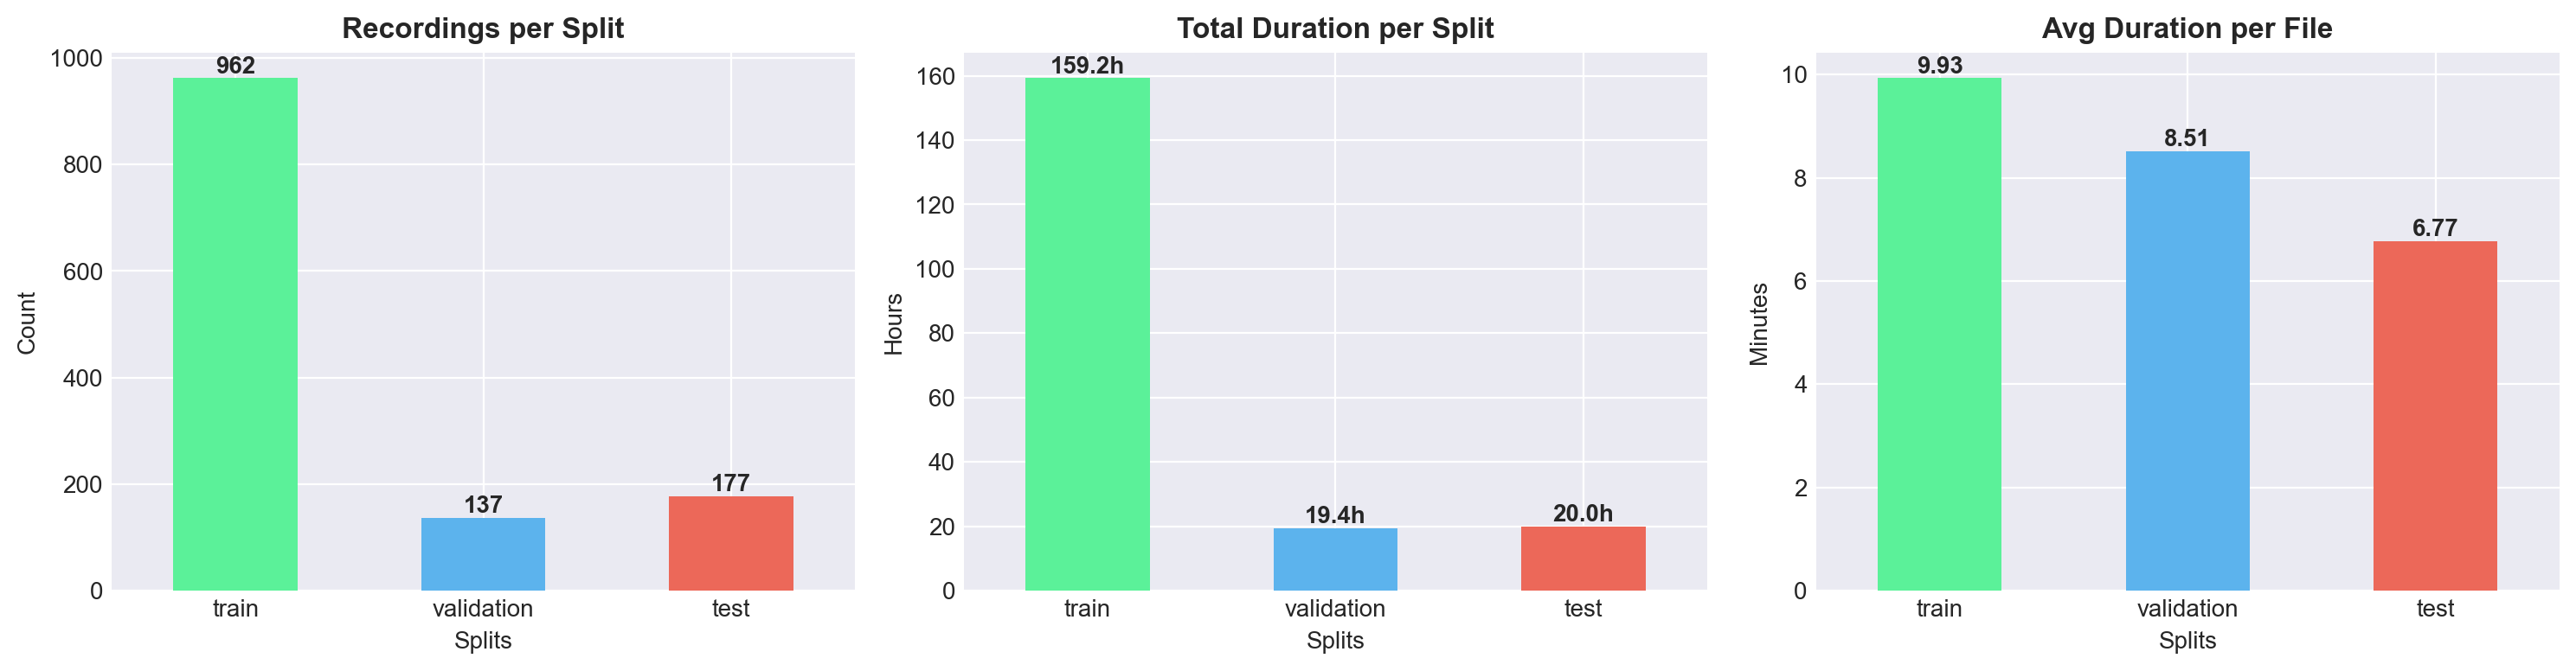

In [10]:
# Split distribution
split_counts = df['split'].value_counts().reindex(['train', 'validation', 'test'])

# Total duration (hours)
split_duration = (
    df.groupby('split')['duration']
    .sum()
    .reindex(['train', 'validation', 'test']) / 3600
)

# Average duration (minutes)
avg_duration_min = (
    df.groupby('split')['duration']
    .mean()
    .reindex(['train', 'validation', 'test']) / 60
)

# Std deviation (minutes)
std_duration_min = (
    df.groupby('split')['duration']
    .std()
    .reindex(['train', 'validation', 'test']) / 60
)

print("\nDetailed Split Statistics:")
for split in split_counts.index:
    print(f"{split.capitalize():12s}: "
          f"{split_counts[split]:4d} files | "
          f"{split_duration[split]:6.1f}h total | "
          f"{avg_duration_min[split]:5.2f} min avg | "
          f"± {std_duration_min[split]:5.2f} min std")
    
fig, axes = plt.subplots(1, 3, figsize=(15, 4))


# Number of recordings
split_counts.plot(kind='bar', ax=axes[0], color=["#5bf199", "#5cb3ed", "#ec6859"])
axes[0].set_title('Recordings per Split', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Splits')
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(split_counts):
    axes[0].text(i, v, str(v), ha='center', va='bottom', fontweight='bold')


# Total duration
split_duration.plot(kind='bar', ax=axes[1], color=["#5bf199", "#5cb3ed", "#ec6859"])
axes[1].set_title('Total Duration per Split', fontweight='bold')
axes[1].set_ylabel('Hours')
axes[1].set_xlabel('Splits')
axes[1].tick_params(axis='x', rotation=0)

for i, v in enumerate(split_duration):
    axes[1].text(i, v, f'{v:.1f}h', ha='center', va='bottom', fontweight='bold')


avg_duration_min.plot(kind='bar', ax=axes[2], color=["#5bf199", "#5cb3ed", "#ec6859"])
axes[2].set_title('Avg Duration per File', fontweight='bold')
axes[2].set_ylabel('Minutes')
axes[2].set_xlabel('Splits')
axes[2].tick_params(axis='x', rotation=0)

for i, v in enumerate(avg_duration_min):
    axes[2].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
fig.savefig("../images/splits.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()



In [11]:
# Global average and std (in minutes)
total_avg_duration_min = df['duration'].mean() / 60
total_std_duration_min = df['duration'].std() / 60

print("\nOverall Dataset Statistics:")
print(f"Average duration: {total_avg_duration_min:.2f} min")
print(f"Std deviation : {total_std_duration_min:.2f} min")


Overall Dataset Statistics:
Average duration: 9.34 min
Std deviation : 7.38 min


Categorical variables

In [12]:
composers = df['canonical_composer'].unique()

print('Unique number of composers and combinations', len(composers))
print(composers)

Unique number of composers and combinations 60
['Alban Berg' 'Alexander Scriabin' 'Antonio Soler' 'Carl Maria von Weber'
 'Charles Gounod / Franz Liszt' 'Claude Debussy' 'César Franck'
 'Domenico Scarlatti' 'Edvard Grieg' 'Felix Mendelssohn'
 'Felix Mendelssohn / Sergei Rachmaninoff' 'Franz Liszt'
 'Franz Liszt / Camille Saint-Saëns' 'Franz Liszt / Vladimir Horowitz'
 'Franz Schubert' 'Franz Schubert / Franz Liszt'
 'Franz Schubert / Leopold Godowsky'
 'Fritz Kreisler / Sergei Rachmaninoff' 'Frédéric Chopin' 'George Enescu'
 'George Frideric Handel' 'Georges Bizet / Ferruccio Busoni'
 'Georges Bizet / Moritz Moszkowski' 'Georges Bizet / Vladimir Horowitz'
 'Giuseppe Verdi / Franz Liszt' 'Henry Purcell' 'Isaac Albéniz'
 'Isaac Albéniz / Leopold Godowsky' 'Jean-Philippe Rameau'
 'Johann Christian Fischer / Wolfgang Amadeus Mozart' 'Johann Pachelbel'
 'Johann Sebastian Bach' 'Johann Sebastian Bach / Egon Petri'
 'Johann Sebastian Bach / Ferruccio Busoni'
 'Johann Sebastian Bach / Franz Li

Top composers

Recording duration plots

Duration Statistics (seconds):
count    1276.000000
mean      560.463595
std       443.057431
min        45.155208
25%       261.981576
50%       429.168241
75%       685.018817
max      2624.663508
Name: duration, dtype: float64


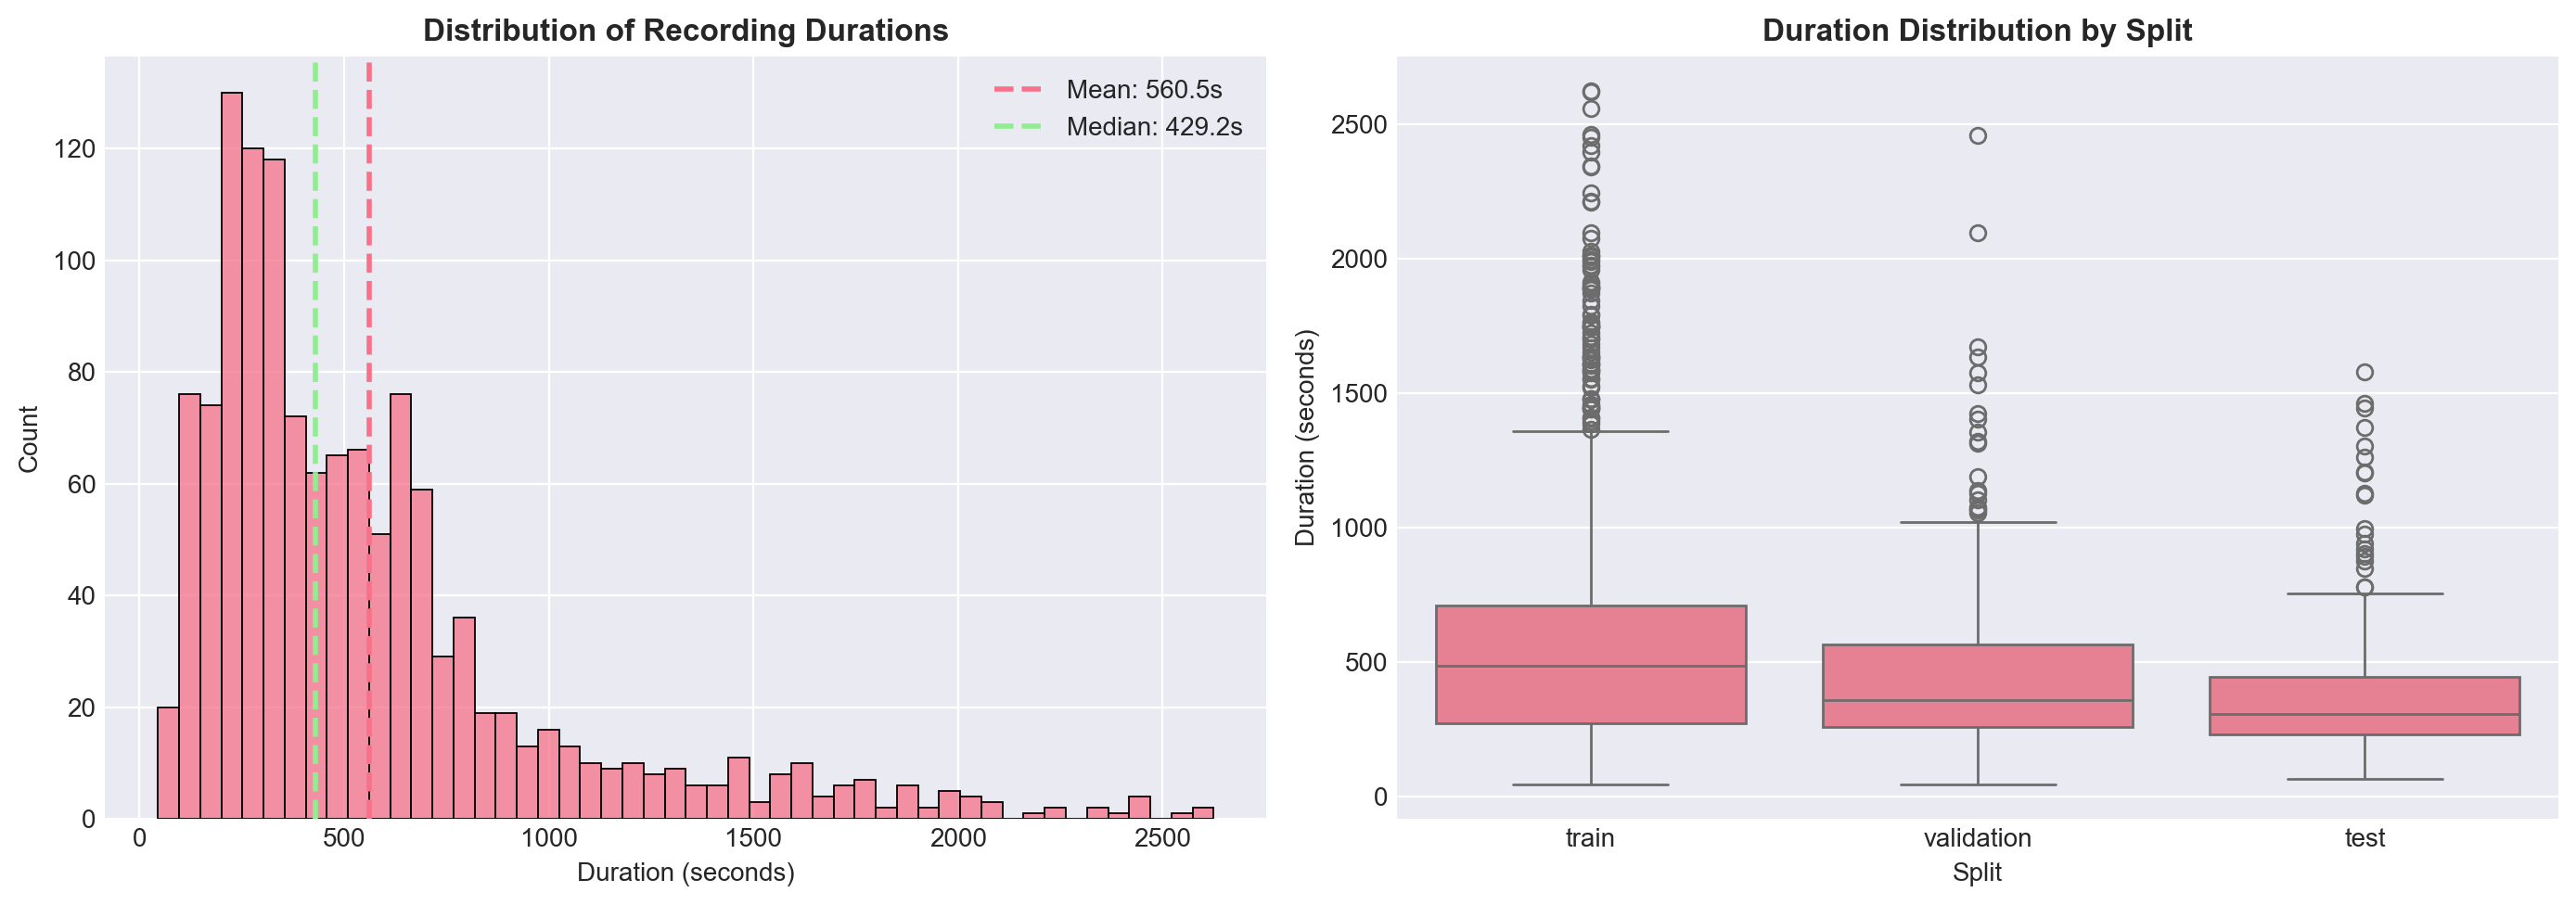

In [ ]:
# Duration statistics
print("Duration Statistics (seconds):")
print(df['duration'].describe())


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ax1 = sns.histplot(
    data=df,
    x='duration',
    bins=50,
    ax=axes[0]
)

mean_val = df['duration'].mean()
median_val = df['duration'].median()

ax1.axvline(mean_val, linestyle='--', linewidth=2,
            label=f'Mean: {mean_val:.1f}s')
ax1.axvline(median_val, linestyle='--', linewidth=2,
            label=f'Median: {median_val:.1f}s', color = 'lightgreen')

ax1.set_title('Distribution of Recording Durations', fontweight='bold')
ax1.set_xlabel('Duration (seconds)')
ax1.set_ylabel('Count')
ax1.legend()


# Boxplot by Split
ax2 = sns.boxplot(
    data=df,
    x='split',
    y='duration',
    ax=axes[1]
)

ax2.set_title('Duration Distribution by Split', fontweight='bold')
ax2.set_xlabel('Split')
ax2.set_ylabel('Duration (seconds)')


plt.tight_layout()

fig.savefig("../images/duration.png",
            dpi=300,
            bbox_inches="tight")

plt.show()


Recordings per year


Recordings by Competition Year:
2004: 132 recordings,  23.2 hours
2006: 115 recordings,  25.3 hours
2008: 147 recordings,  14.6 hours
2009: 125 recordings,  23.0 hours
2011: 163 recordings,  15.6 hours
2013: 127 recordings,  14.4 hours
2014: 105 recordings,  24.8 hours
2015: 129 recordings,  14.3 hours
2017: 140 recordings,  16.1 hours
2018:  93 recordings,  27.4 hours


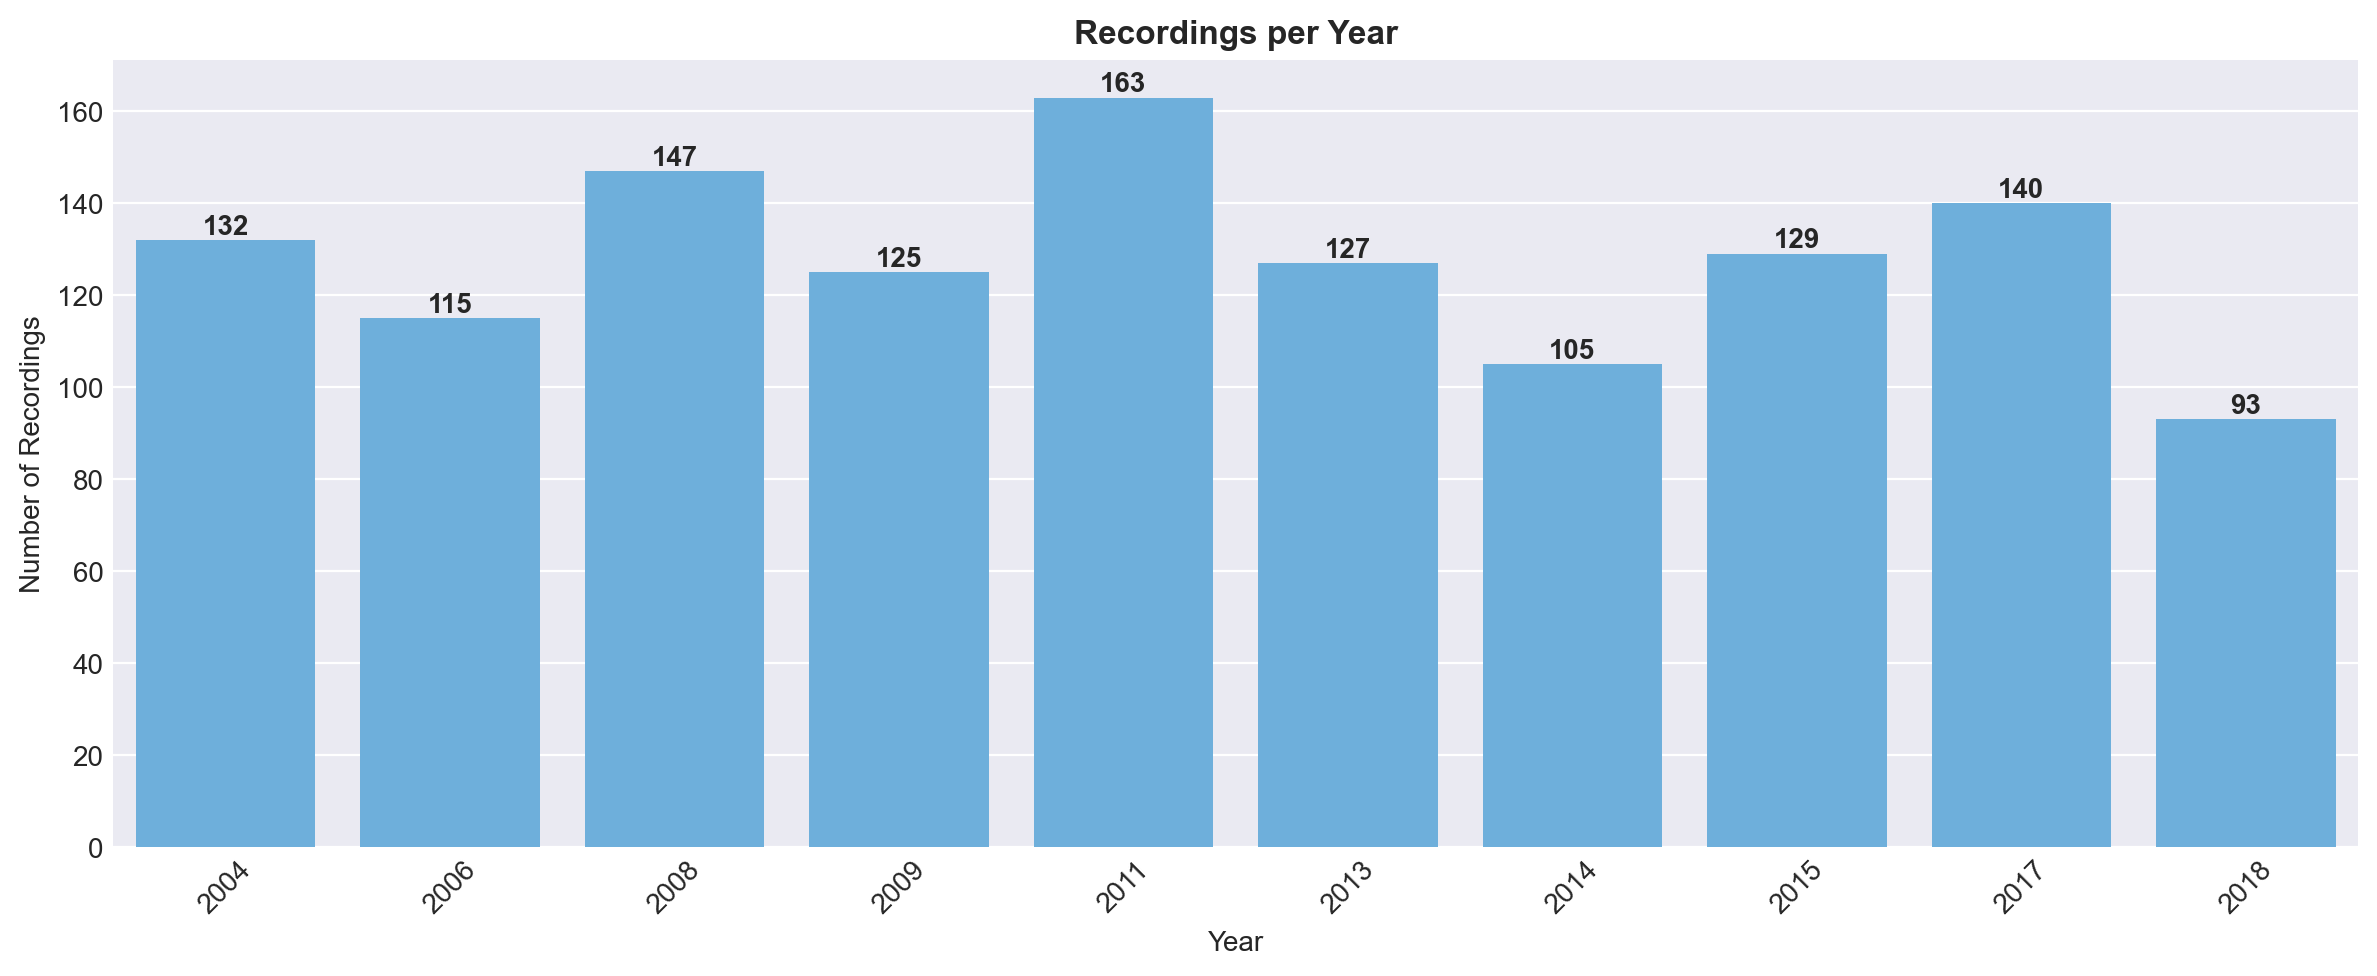

In [30]:
# Recordings by year
year_counts = df['year'].value_counts().sort_index()

print("Recordings by Competition Year:")
for year, count in year_counts.items():
    duration = df[df['year'] == year]['duration'].sum() / 3600
    print(f"{year}: {count:3d} recordings, {duration:5.1f} hours")


plt.figure(figsize=(12, 5))

ax = sns.barplot(
    x=year_counts.index,
    y=year_counts.values,
    color="#5cb3ed"
)

ax.set_title('Recordings per Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Recordings')

plt.xticks(rotation=45)

# Add value labels
for i, v in enumerate(year_counts.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

fig.savefig("../images/year_count.png",
            dpi=300,
            bbox_inches="tight")

plt.tight_layout()
plt.show()
